In [9]:
import pyzx as zx
import random
import matplotlib.pyplot as plt


def chsh_game(strategy):
    # Definimos el juego CHSH. La función strategy es la estrategia de Alice y Bob, que toma como entrada sus bits x e y, y devuelve sus respuestas a y b respectivamente.
    x, y = random.randint(0, 1), random.randint(0, 1)
    a, b = strategy(x, y)
    
    if (a != b) == (x & y):
        return 1
    return 0


# -Ahora construimos el circuito para la estrategia cuántica óptima. Alice y Bob comparten un e-bit, y luego aplican rotaciones Ry dependiendo de sus bits de entrada x e y. Finalmente, miden sus qubits para obtener sus respuestas a y b.
def chsh_circuit(x, y):
    
    c = zx.Circuit(2)
    
   
    c.add_gate("H", 0)
    c.add_gate("CNOT", 0, 1)
    
    
    def add_ry(circ, qubit, phase_fraction):
        circ.add_gate("XPhase", qubit, phase=0.5)
        circ.add_gate("ZPhase", qubit, phase=phase_fraction)
        circ.add_gate("XPhase", qubit, phase=-0.5)

    # Acciones de Alice
    if x == 0:
        pass
    else:
        add_ry(c, 0, -0.5)
        
    # Acciones de Bob
    if y == 0:
        add_ry(c, 1, -0.25)
    else:
        add_ry(c, 1, 0.25)
        
    return c

(x,y) = (0,0)


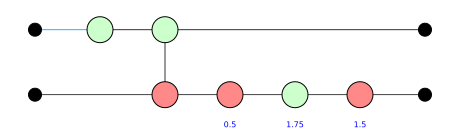

(x,y) = (0,1)


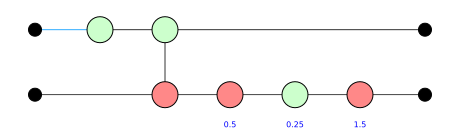

(x,y) = (1,0)


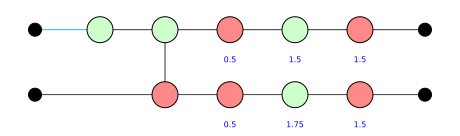

(x,y) = (1,1)


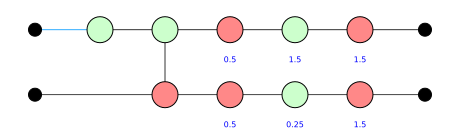

In [10]:
# Dibujar los cuatro circuitos posibles

print("(x,y) = (0,0)")
fig = zx.draw_matplotlib(chsh_circuit(0, 0))
display(fig)
plt.close(fig)

print("(x,y) = (0,1)")
fig = zx.draw_matplotlib(chsh_circuit(0, 1))
display(fig)
plt.close(fig)

print("(x,y) = (1,0)")
fig = zx.draw_matplotlib(chsh_circuit(1, 0))
display(fig)
plt.close(fig)

print("(x,y) = (1,1)")
fig = zx.draw_matplotlib(chsh_circuit(1, 1))
display(fig)
plt.close(fig)